In [1]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm
import glob
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from ipywidgets import interact
import ipywidgets as widgets
import matplotlib
import xarray as xr
import netCDF4

# Change working directory
import os
os.chdir(os.getcwd() + "/../")
print(os.getcwd())

import config
from utils.analysis import rotate_umap

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation


## Load NEMI data

In [2]:
nemi_dfs = []
for file in Path(config.output_dir_nemi).glob("volume_nemi_iteration*.csv"):
    temp = pd.read_csv(file)
    temp["iteration"] = int(str(file).split("_")[-1].lstrip("iteration").rstrip(".csv"))
    nemi_dfs.append(temp)

In [3]:
len(nemi_dfs)

100

In [4]:
nemi_dfs = pd.concat(nemi_dfs)

## Analyse NEMI uncertainties
Choose final cluster set as the run with lowest mean uncertainty

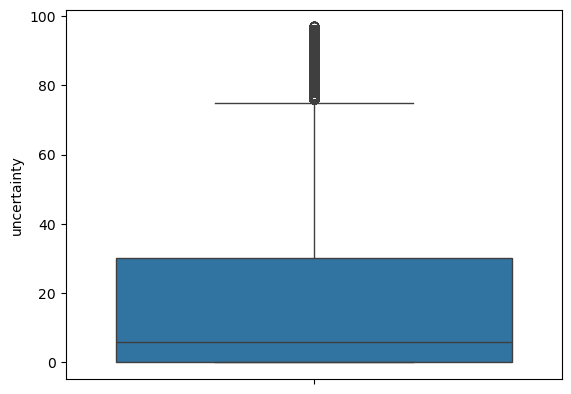

Mean NEMI uncertainty: (17.27 +- 22.1%)


In [5]:
# Uncertainties across all ensemble members
sns.boxplot(nemi_dfs["uncertainty"])
plt.show()
print(f"Mean NEMI uncertainty: ({np.round(nemi_dfs.uncertainty.mean(), 2)} +- {np.round(nemi_dfs.uncertainty.std(), 1)}%)")

In [6]:
# Check uncertainties per enxemble member
uncertainty_per_member = (
    nemi_dfs[["iteration", "uncertainty"]]
    .groupby("iteration")
    .agg(mean_uncertainty=("uncertainty", "mean"),
         std_uncertainty=("uncertainty", "std"))
    .reset_index()
)

uncertainty_per_member.sort_values("mean_uncertainty")

,iteration,mean_uncertainty,std_uncertainty
29,29,15.637834,20.056412
84,84,15.683643,19.982883
42,42,15.706914,20.286852
82,82,15.772241,20.307364
3,3,15.793922,20.411317
...,...,...,...
57,57,19.262696,23.926266
86,86,19.360188,24.978094
21,21,19.611564,25.755686
70,70,20.375974,23.914845


In [14]:
print(f"Std of mean uncertainties: {round(uncertainty_per_member.mean_uncertainty.std(), 1)}%") 

Std of mean uncertainties: 1.0%


## Final cluster set

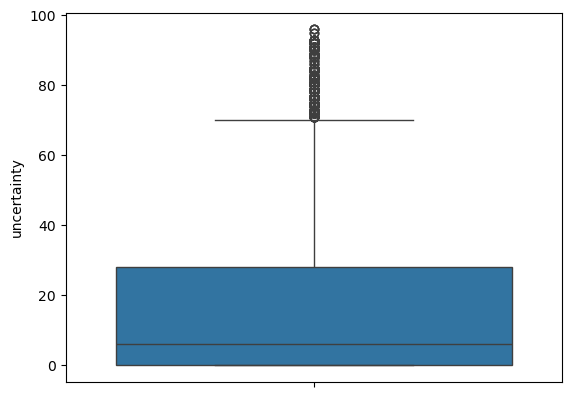

Base id 29.0 has the lowest mean uncertainty across the ensemble (15.64 +- 20.1%)


In [7]:
# Determine final cluster set (lowest mean uncertainty)
final_cluster_id = uncertainty_per_member[uncertainty_per_member["mean_uncertainty"] == uncertainty_per_member["mean_uncertainty"].min()].iloc[0]["iteration"]
final_df = nemi_dfs[nemi_dfs["iteration"] == final_cluster_id]

# Plot uncertainties of final cluster set
sns.boxplot(final_df["uncertainty"])
plt.show()

print(f"Base id {final_cluster_id} has the lowest mean uncertainty across the ensemble ({np.round(final_df.uncertainty.mean(), 2)} +- {np.round(final_df.uncertainty.std(), 1)}%)")

In [9]:
# Store final CSV
final_df.loc[:, ["e0", "e1", "e2"]] = rotate_umap(final_df[["e0", "e1", "e2"]], x=180, y=0, z=0, factor=-1)  # Rotate embedding
final_df = final_df.drop(["label", "sorted_label", "iteration"], axis=1).rename(columns={"final_label": "label", "label_color": "color"}) 
final_df.to_csv(f"{config.output_dir}cluster_set.csv", index=False)

In [15]:
# Convert DataFrame to xarray 
dx = xr.Dataset.from_dataframe(final_df.set_index(['LEV_M', 'LATITUDE', 'LONGITUDE']))

# Save xarray Dataset to NetCDF file
dx.to_netcdf(f"{config.output_dir}cluster_set.nc")